In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv


In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. PANDAS: Data load karna aur prepare karna
file_path = '/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv'
df = pd.read_csv(file_path)

print(df.info())
df.drop(columns = ["RowNumber","CustomerId","Surname"], inplace = True)
df['BalanceSalaryRatio'] = df['Balance'] / df['EstimatedSalary'] 
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,BalanceSalaryRatio
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.000000
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.744677
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1.401375
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.000000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1.587055
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0.000000
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0.564108
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,0.000000
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,0.808230


Analyzing the data and information present in churn_modelling csv file

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. PANDAS: Data load karna aur prepare karna
file_path = '/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv'
df = pd.read_csv(file_path)
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

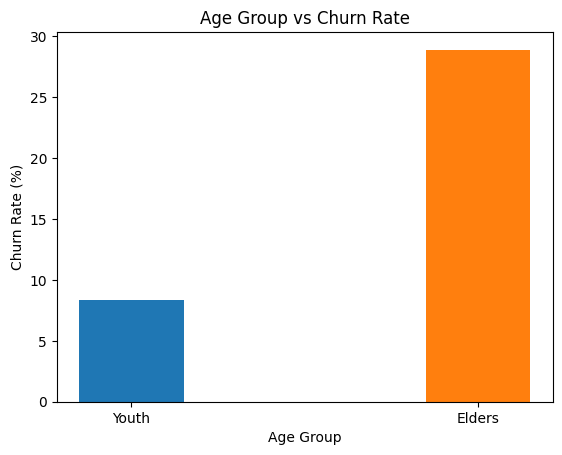

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

file_path = '/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv'
df = pd.read_csv(file_path)

ax = ['Youth','Elders']
# p = ['Elders']
w = 0.3
young_gen = df[df['Age']<=35] 
old_gen = df[df['Age']>35]
# print(young_gen['Exited'].value_counts())
# print(old_gen['Exited'].value_counts())
young_churnRate = (young_gen['Exited'].value_counts()[1]/(young_gen['Exited'].value_counts()[1]+young_gen['Exited'].value_counts()[0]))*100
old_churnRate = (old_gen['Exited'].value_counts()[1]/(old_gen['Exited'].value_counts()[1]+old_gen['Exited'].value_counts()[0]))*100
plt.bar(ax[0],young_churnRate, width = w)
plt.bar(ax[1],old_churnRate, width = w)

plt.title("Age Group vs Churn Rate")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")

plt.show()

**Conclusion**: The above bar chart clearly shows that elders are churning more as compared to younger.So, i would analyze the elders data in different countries to check the reason of there churning.

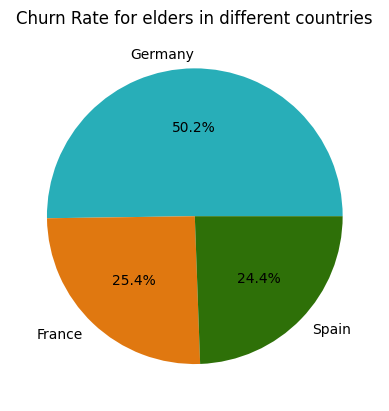

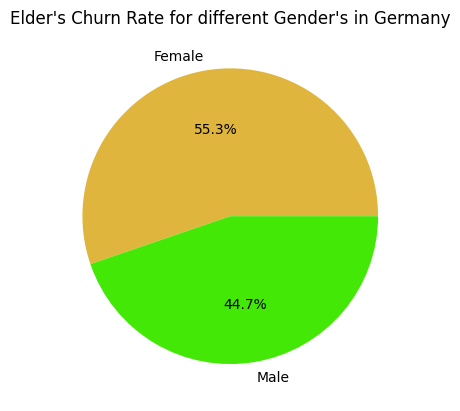

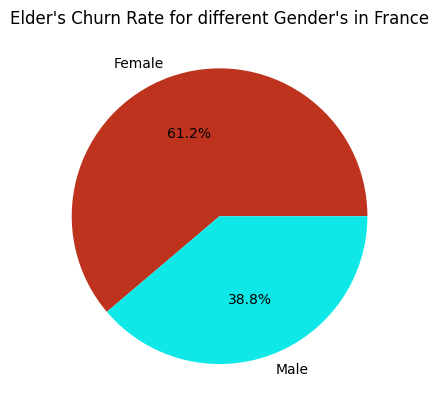

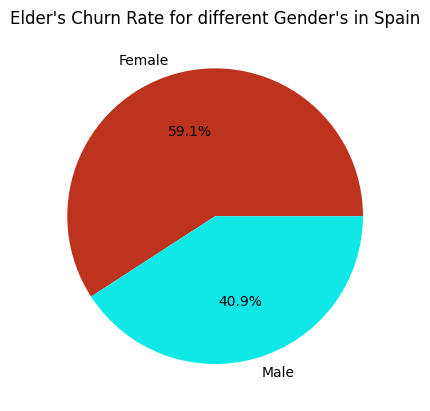

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

file_path = '/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv'
df = pd.read_csv(file_path)

# Churn Rate VS Coutries
count=df[(df['Exited']==1) & (df['Age']>35)] ['Geography'].value_counts()
churn_ger = (count['Germany']/df['Geography'].value_counts()['Germany'])*100
churn_fra = (count['France']/df['Geography'].value_counts()['France'])*100
churn_spa = (count['Spain']/df['Geography'].value_counts()['Spain'])*100

group_churn = [churn_ger,churn_fra,churn_spa]
plt.pie(group_churn,labels = ['Germany','France','Spain'], autopct='%1.1f%%',colors = ['#28aeb8','#e07810','#2e7008'])
plt.title("Churn Rate for elders in different countries")
plt.show()
# Churn Rate relation with gender
lis = df[(df['Age'] > 35) & (df['Geography']=='Germany') ].groupby('Gender')['Exited'].mean() * 100
plt.pie(lis,labels = ['Female','Male'],autopct='%1.1f%%',colors = ['#e0b53d','#43e807'])
plt.title("Elder's Churn Rate for different Gender's in Germany")
plt.show()

# For France
lis_fr = df[(df['Age'] > 35) & (df['Geography']=='France') ].groupby('Gender')['Exited'].mean() * 100
plt.pie(lis_fr,labels = ['Female','Male'],autopct='%1.1f%%',colors = ['#bd331e','#10e8e8'])
plt.title("Elder's Churn Rate for different Gender's in France")
plt.show()

# For Spain
lis_sp = df[(df['Age'] > 35) & (df['Geography']=='Spain') ].groupby('Gender')['Exited'].mean() * 100
plt.pie(lis_sp,labels = ['Female','Male'],autopct='%1.1f%%',colors = ['#bd331e','#10e8e8'])
plt.title("Elder's Churn Rate for different Gender's in Spain")
plt.show()



**Conclusion**: The above pie chart clearly shows the following things:-
        1. Elders(Age>35) present in Germany are churing more with respect to other countries.
        2. Females in every country are churning more than males. 

**Recommendation**:- Bank should focus on there elder female customers especially in Germany by launching attractive credit card offers or some health insurance schemes that can attract there female customers in every country. 

Balance_Group  Non-Zero Balance  Zero Balance
Geography                                    
France                26.983051     21.259259
Germany               43.469910           NaN
Spain                 25.677419     18.540146


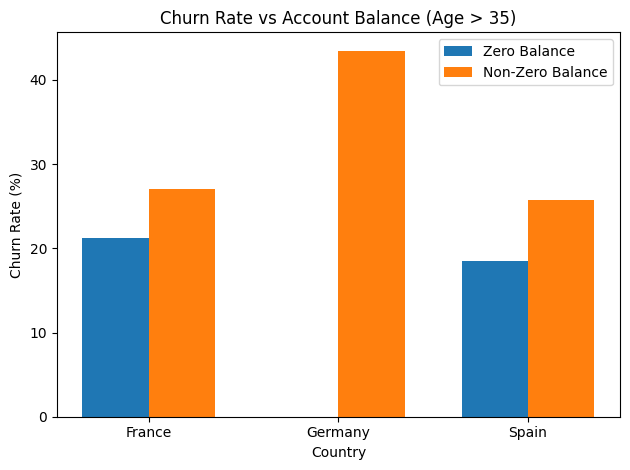

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

file_path = '/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv'

df = pd.read_csv(file_path)

# Only customers older than 35
temp = df[df['Age'] > 35].copy()

# Create balance groups
temp['Balance_Group'] = np.where(
    temp['Balance'] == 0,
    'Zero Balance',
    'Non-Zero Balance'
)

# Calculate churn rate
churn_rate = (
    temp.groupby(['Geography', 'Balance_Group'])['Exited']
        .mean()
        .mul(100)
        .unstack()
)

print(churn_rate)

# Plot
countries = churn_rate.index
x = np.arange(len(countries))
w = 0.35

plt.bar(
    x - w/2,
    churn_rate['Zero Balance'],
    width=w,
    label='Zero Balance'
)

plt.bar(
    x + w/2,
    churn_rate['Non-Zero Balance'],
    width=w,
    label='Non-Zero Balance'
)

plt.xticks(x, countries)

plt.ylabel('Churn Rate (%)')
plt.xlabel('Country')
plt.title('Churn Rate vs Account Balance (Age > 35)')

plt.legend()
plt.tight_layout()
plt.show()

**The data clearly shows that very much churn rate is not getting affected due to 0 balance account for elders in any country**.
**Recommendation**: Although bank can run "**Zero balance Active Customer Programme**" like if a customer uses the account 5 times in month they can unlock benefits like reward points,merchant coupans etc.

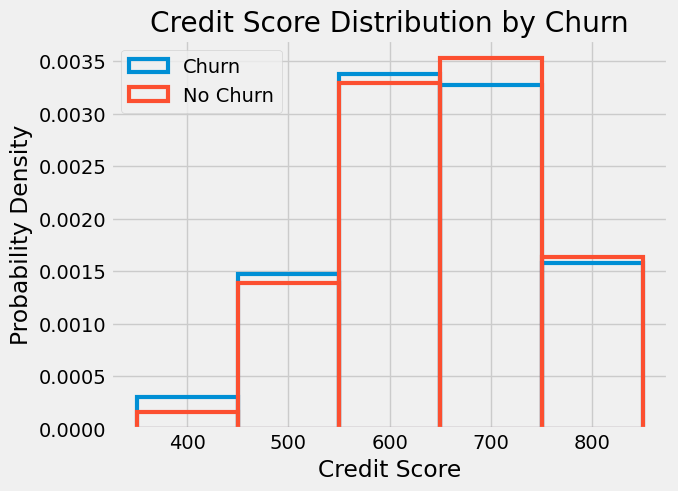

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('fivethirtyeight')
file_path = '/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv'
df = pd.read_csv(file_path)
bins = [350, 450, 550, 650, 750, 850]
style = {'facecolor': 'none', 'edgecolor': 'C0', 'linewidth': 3}
st = {'facecolor': 'none', 'edgecolor': 'C1', 'linewidth': 3}
# Setting density = true because there are large number of customers who didn't churn
plt.hist(df[df['Exited']==1]['CreditScore'],bins = bins,label='Churn',**style,density = True)
plt.hist(df[df['Exited']==0]['CreditScore'],bins = bins,label='No Churn',**st,density = True)
plt.legend()

plt.xlabel('Credit Score')
plt.ylabel('Probability Density')
plt.title('Credit Score Distribution by Churn')
plt.show()

*Conclusion*: **The histogram shows that both churn and non-churn customer's density is mainly concentrated in the mid-to-high credit score range (around 550–750)**. However, there are substantially more non-churn customers than churn customers across most credit-score ranges.
*So,we tried to find density which shows around(350-650 credit score) there is a high probability of churned customers and for 650-850 there is a low probability of churned customers*.

*Recommendation*: The bank can run "Credit Recovery and Retention programme" in which instead of giving direct loan they can give small, controlled credit card facility and help the customer to check there credit score usage by a financial health assessment so that he/she can control there credit score.

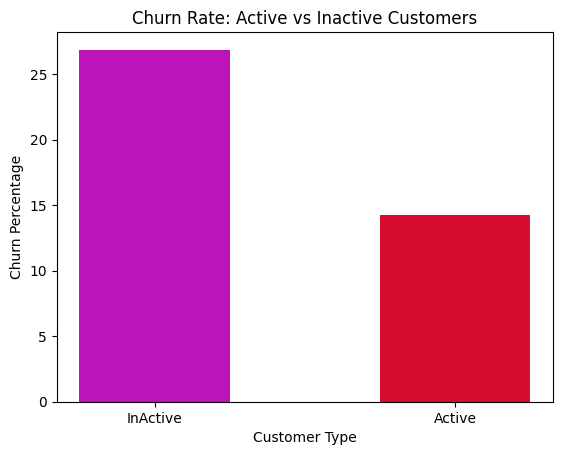

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

file_path = '/kaggle/input/datasets/saurabhbadole/bank-customer-churn-prediction-dataset/Churn_Modelling.csv'
df = pd.read_csv(file_path)

a = df.groupby('IsActiveMember')['Exited'].mean()*100
x = ['InActive','Active']
# print(a)
plt.bar(x,a,color = ['#bd13ba','#d60d2e'], width = 0.5)
plt.xlabel('Customer Type')
plt.ylabel('Churn Percentage')
plt.title('Churn Rate: Active vs Inactive Customers')
plt.show()

*Conclusion*: That bar chart shows that inactive customers are churning more as compared to active customers

*Recommendation*:   
                    1.The bank should identify the reason first and can encourage bill payments,salary/DBT credits etc.
                    2.The bank can start "Welcome Back" offer by giving cashback to maintain a minimum balance account or merchant benefits after reactivation.